# Part 1 Taxi: Statistics, EDA, and Visualizations

## NYC Yellow Taxi Analysis — January 2023

This third notebook performs some statistical analysis and exploratory data analysis (EDA) on the curated NYC Yellow Taxi dataset.

### Notebook Structure

1. Data Loading
2. Required Groupby Metrics
3. Window-Style Metrics
4. Exploratory Data Analysis (EDA)
5. Visualizations
6. Summary of Findings

## -> Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.max_rows", 200)

sns.set_theme(style="whitegrid")

In [ ]:
curated_path = "../data/curated/part1_taxi_curated.parquet"
df = pd.read_parquet(curated_path)

#make sure datetime columns are proper datetimes
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"], errors="coerce")
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"], errors="coerce")

#start analysis copy
analysis_df = df.copy()

#remove rows with missing datetimes
analysis_df = analysis_df[
    analysis_df["tpep_pickup_datetime"].notna() &
    analysis_df["tpep_dropoff_datetime"].notna()
].copy()

#keep only January 2023 pickups
analysis_df = analysis_df[
    (analysis_df["tpep_pickup_datetime"] >= "2023-01-01") &
    (analysis_df["tpep_pickup_datetime"] < "2023-02-01")
].copy()

#recompute duration for safety
analysis_df["trip_duration_min"] = (
    analysis_df["tpep_dropoff_datetime"] - analysis_df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

#remove invalid rows again for analysis safety
analysis_df = analysis_df[
    (analysis_df["trip_duration_min"] > 0) &
    (analysis_df["trip_distance"] > 0) &
    (analysis_df["passenger_count"] > 0) &
    (analysis_df["total_amount"] > 0)
].copy()

#drop duplicates
dedupe_key = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "PULocationID",
    "DOLocationID",
    "total_amount"
]
analysis_df = analysis_df.drop_duplicates(subset=dedupe_key).copy()

#rebuild time-based columns from cleaned pickup datetime
analysis_df["pickup_date"] = analysis_df["tpep_pickup_datetime"].dt.date
analysis_df["pickup_hour"] = analysis_df["tpep_pickup_datetime"].dt.hour
analysis_df["weekday"] = analysis_df["tpep_pickup_datetime"].dt.day_name()
analysis_df["week_of_year"] = analysis_df["tpep_pickup_datetime"].dt.isocalendar().week.astype(int)

print("Original curated dataset shape:", df.shape)
print("Analysis dataset shape after cleaning:", analysis_df.shape)
print("Min pickup datetime:", analysis_df["tpep_pickup_datetime"].min())
print("Max pickup datetime:", analysis_df["tpep_pickup_datetime"].max())

analysis_df.head()

Original curated dataset shape: (2884396, 23)
Analysis dataset shape after cleaning: (2884354, 23)
Min pickup datetime: 2023-01-01 00:00:05
Max pickup datetime: 2023-01-31 23:59:59


,PULocationID,DOLocationID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,fare_amount,tip_amount,total_amount,payment_type,PU_borough,PU_zone,DO_borough,DO_zone,pickup_date,pickup_hour,weekday,week_of_year,trip_duration_min,speed_mph,fare_per_mile,tip_rate,distance_bucket
0,161,141,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,9.3,0.00,14.30,2,Manhattan,Midtown Center,Manhattan,Lenox Hill West,2023-01-01,0,Sunday,52,8.433333,6.901186,9.587629,0.000000,"[0,1)"
1,43,237,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,7.9,4.00,16.90,1,Manhattan,Central Park,Manhattan,Upper East Side South,2023-01-01,0,Sunday,52,6.316667,10.448549,7.181818,0.236686,"[1,3)"
2,48,238,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,14.9,15.00,34.90,1,Manhattan,Clinton East,Manhattan,Upper West Side North,2023-01-01,0,Sunday,52,12.750000,11.811765,5.936255,0.429799,"[1,3)"
3,107,79,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,11.4,3.28,19.68,1,Manhattan,Gramercy,Manhattan,East Village,2023-01-01,0,Sunday,52,10.833333,7.920000,7.972028,0.166667,"[1,3)"
4,161,137,2023-01-01 00:50:34,2023-01-01 01:02:52,1.0,1.84,12.8,10.00,27.80,1,Manhattan,Midtown Center,Manhattan,Kips Bay,2023-01-01,0,Sunday,52,12.300000,8.975610,6.956522,0.359712,"[1,3)"


In [41]:
raw_path = "../data/raw/tlc/yellow_tripdata_2023-01.parquet"
raw_df = pd.read_parquet(raw_path)

print("Raw dataset shape:", raw_df.shape)
raw_df.head()

Raw dataset shape: (3066766, 19)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00


In [42]:
print("Analysis dataset info:")
analysis_df.info()

print("\nMissing values in analysis dataset:")
print(analysis_df.isna().sum().sort_values(ascending=False).head(15))

print("\nUnique boroughs:")
print(sorted(analysis_df["PU_borough"].dropna().unique()))

print("\nUnique weekdays:")
print(sorted(analysis_df["weekday"].dropna().unique()))

print("\nUnique distance buckets:")
print(analysis_df["distance_bucket"].dropna().unique())

print("\nDate range in analysis dataset:")
print(analysis_df["pickup_date"].min(), "to", analysis_df["pickup_date"].max())

print("\nNumber of unique pickup dates:")
print(analysis_df["pickup_date"].nunique())

Analysis dataset info:
<class 'pandas.core.frame.DataFrame'>
Index: 2884354 entries, 0 to 2884395
Data columns (total 23 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   PULocationID           int64         
 1   DOLocationID           int64         
 2   tpep_pickup_datetime   datetime64[us]
 3   tpep_dropoff_datetime  datetime64[us]
 4   passenger_count        float64       
 5   trip_distance          float64       
 6   fare_amount            float64       
 7   tip_amount             float64       
 8   total_amount           float64       
 9   payment_type           int64         
 10  PU_borough             object        
 11  PU_zone                object        
 12  DO_borough             object        
 13  DO_zone                object        
 14  pickup_date            object        
 15  pickup_hour            int32         
 16  weekday                object        
 17  week_of_year           int64         
 18  trip

## A. Required Groupby Metrics

1. Daily trip counts grouped by PU_borough and pickup_date.
2. Mean and median of fare_amount and trip_distance grouped by PU_borough and weekday.
3. For each pickup_hour, the proportion of trips by payment_type.
4. Mean tip_rate grouped by distance_bucket.

#### -> Daily trip counts

In [43]:
daily_trip_counts = (
    analysis_df.groupby(["PU_borough", "pickup_date"])
    .size()
    .reset_index(name="daily_trip_count")
    .sort_values(["PU_borough", "pickup_date"])
)

print("Daily trip counts by borough and date:")
display(daily_trip_counts.head(20))

Daily trip counts by borough and date:


,PU_borough,pickup_date,daily_trip_count
0,Bronx,2023-01-01,91
1,Bronx,2023-01-02,61
2,Bronx,2023-01-03,122
3,Bronx,2023-01-04,165
4,Bronx,2023-01-05,140
5,Bronx,2023-01-06,114
6,Bronx,2023-01-07,76
7,Bronx,2023-01-08,45
8,Bronx,2023-01-09,94
9,Bronx,2023-01-10,121


#### -> Mean and median of fare_amount and trip_distance grouped by PU_borough and weekday.

In [44]:
weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
analysis_df["weekday"] = pd.Categorical(
    analysis_df["weekday"],
    categories=weekday_order,
    ordered=True
)

borough_weekday_stats = (
    analysis_df.groupby(["PU_borough", "weekday"], observed=False)
    .agg(
        fare_amount_mean=("fare_amount", "mean"),
        fare_amount_median=("fare_amount", "median"),
        trip_distance_mean=("trip_distance", "mean"),
        trip_distance_median=("trip_distance", "median")
    )
    .reset_index()
    .sort_values(["PU_borough", "weekday"])
)

print("Mean and median fare_amount and trip_distance by borough and weekday:")
display(borough_weekday_stats.head(30))

Mean and median fare_amount and trip_distance by borough and weekday:


,PU_borough,weekday,fare_amount_mean,fare_amount_median,trip_distance_mean,trip_distance_median
0,Bronx,Monday,31.415012,29.2,7.375206,5.700
1,Bronx,Tuesday,32.212044,28.7,7.736332,5.740
2,Bronx,Wednesday,29.428251,25.5,6.578189,4.775
3,Bronx,Thursday,29.725138,25.4,6.898687,4.700
4,Bronx,Friday,31.846877,26.2,7.271738,4.690
5,Bronx,Saturday,27.605784,22.5,6.652276,4.250
6,Bronx,Sunday,26.862102,22.5,5.856306,4.400
7,Brooklyn,Monday,27.095067,22.5,5.580576,3.820
8,Brooklyn,Tuesday,26.899318,22.6,5.461105,3.900
9,Brooklyn,Wednesday,26.454092,22.5,5.375369,3.710


#### -> For each pickup_hour, the proportion of trips by payment_type.

In [45]:
payment_type_proportions = (
    analysis_df.groupby(["pickup_hour", "payment_type"])
    .size()
    .reset_index(name="trip_count")
)

payment_type_proportions["hour_total"] = (
    payment_type_proportions.groupby("pickup_hour")["trip_count"].transform("sum")
)

payment_type_proportions["proportion"] = (
    payment_type_proportions["trip_count"] /
    payment_type_proportions["hour_total"]
)

payment_type_proportions = payment_type_proportions.sort_values(
    ["pickup_hour", "payment_type"]
)

print("Proportion of trips by payment type within each pickup hour:")
display(payment_type_proportions.head(30))

hour_check = payment_type_proportions.groupby("pickup_hour")["proportion"].sum()
print("\nCheck: proportions by hour should sum to 1")
display(hour_check.head(10))

Proportion of trips by payment type within each pickup hour:


,pickup_hour,payment_type,trip_count,hour_total,proportion
0,0,1,66033,79558,0.829998
1,0,2,12526,79558,0.157445
2,0,3,340,79558,0.004274
3,0,4,659,79558,0.008283
4,1,1,46789,55573,0.841938
5,1,2,8070,55573,0.145214
6,1,3,226,55573,0.004067
7,1,4,488,55573,0.008781
8,2,1,32393,38733,0.836315
9,2,2,5768,38733,0.148917



Check: proportions by hour should sum to 1


pickup_hour
0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
5    1.0
6    1.0
7    1.0
8    1.0
9    1.0
Name: proportion, dtype: float64

#### -> Mean tip_rate grouped by distance_bucket.

In [46]:
distance_order = ["[0,1)", "[1,3)", "[3,5)", "[5,10)", "[10,+)"]
analysis_df["distance_bucket"] = pd.Categorical(
    analysis_df["distance_bucket"],
    categories=distance_order,
    ordered=True
)

tip_rate_by_distance = (
    analysis_df.groupby("distance_bucket", observed=False)
    .agg(mean_tip_rate=("tip_rate", "mean"))
    .reset_index()
    .sort_values("distance_bucket")
)

print("Mean tip_rate by distance_bucket:")
display(tip_rate_by_distance)

Mean tip_rate by distance_bucket:


,distance_bucket,mean_tip_rate
0,"[0,1)",0.119133
1,"[1,3)",0.123695
2,"[3,5)",0.120473
3,"[5,10)",0.112819
4,"[10,+)",0.111042


## B. Required Window-Style Metrics

1. For each PU_borough, a 7-day rolling mean of daily trip counts ordered by pickup_date.
2. For each PU_borough, the day-over-day difference and day-over-day percent change of daily trip counts.

In [ ]:
daily_metrics = daily_trip_counts.copy()

#make sure rows are ordered corectly within each borough
daily_metrics = daily_metrics.sort_values(["PU_borough", "pickup_date"]).reset_index(drop=True)

#7-day rolling mean of daily trip counts for each borough
daily_metrics["rolling_7day_mean"] = (
    daily_metrics.groupby("PU_borough")["daily_trip_count"]
    .transform(lambda s: s.rolling(window=7, min_periods=1).mean())
)

#day-over-day difference for each borough
daily_metrics["day_over_day_diff"] = (
    daily_metrics.groupby("PU_borough")["daily_trip_count"]
    .diff()
)

#day-over-day percent change for each borough
daily_metrics["day_over_day_pct_change"] = (
    daily_metrics.groupby("PU_borough")["daily_trip_count"]
    .pct_change() * 100
)

print("Daily metrics with rolling mean and day-over-day changes:")
display(daily_metrics.head(20))

Daily metrics with rolling mean and day-over-day changes:


,PU_borough,pickup_date,daily_trip_count,rolling_7day_mean,day_over_day_diff,day_over_day_pct_change
0,Bronx,2023-01-01,91,91.000000,NaN,NaN
1,Bronx,2023-01-02,61,76.000000,-30.0,-32.967033
2,Bronx,2023-01-03,122,91.333333,61.0,100.000000
3,Bronx,2023-01-04,165,109.750000,43.0,35.245902
4,Bronx,2023-01-05,140,115.800000,-25.0,-15.151515
5,Bronx,2023-01-06,114,115.500000,-26.0,-18.571429
6,Bronx,2023-01-07,76,109.857143,-38.0,-33.333333
7,Bronx,2023-01-08,45,103.285714,-31.0,-40.789474
8,Bronx,2023-01-09,94,108.000000,49.0,108.888889
9,Bronx,2023-01-10,121,107.857143,27.0,28.723404


## C. Required EDA Questions

1. Which borough has the strongest weekday effect? Quantified using eqn provided.
2. Identify two specific dates with anomalous total trip volume using a z-score on daily totals. Show the z-scores and the two selected dates.
3. Determine whether tip_rate is more strongly associated with pickup_hour or distance_bucket. Use a quantitative comparison and report your conclusion.

### -> EDA Question 1
#### Which borough has the strongest weekday effect?

We quantify weekday effect for each borough using:

\[
S_{borough} = \frac{\max(\mu_{weekday, borough}) - \min(\mu_{weekday, borough})}{\mu_{borough}}
\]

where:
- \(\mu_{weekday, borough}\) = mean daily trips for that weekday within the borough
- \(\mu_{borough}\) = overall mean daily trips for the borough

In [ ]:
#start from daily_trip_counts and add weekday from pickup_date
weekday_daily = daily_trip_counts.copy()
weekday_daily["pickup_date"] = pd.to_datetime(weekday_daily["pickup_date"])
weekday_daily["weekday"] = weekday_daily["pickup_date"].dt.day_name()

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_daily["weekday"] = pd.Categorical(
    weekday_daily["weekday"],
    categories=weekday_order,
    ordered=True
)

#mean daily trips for each weekday within each borough
weekday_means = (
    weekday_daily
    .groupby(["PU_borough", "weekday"], observed=False)["daily_trip_count"]
    .mean()
    .reset_index(name="mean_daily_trips_for_weekday")
)

#overall mean daily trips for each borough
borough_means = (
    weekday_daily
    .groupby("PU_borough")["daily_trip_count"]
    .mean()
    .reset_index(name="overall_mean_daily_trips")
)

#compute max and min weekday means for each borough
weekday_effect = (
    weekday_means
    .groupby("PU_borough")["mean_daily_trips_for_weekday"]
    .agg(max_weekday_mean="max", min_weekday_mean="min")
    .reset_index()
)

#merge with overall borough means
weekday_effect = weekday_effect.merge(borough_means, on="PU_borough", how="left")

#compute S_borough according to assignment formula
weekday_effect["S_borough"] = (
    (weekday_effect["max_weekday_mean"] - weekday_effect["min_weekday_mean"])
    / weekday_effect["overall_mean_daily_trips"]
)

#sort from strongest to weakest weekday effect
weekday_effect = weekday_effect.sort_values("S_borough", ascending=False)

display(weekday_effect)

#restrict to actual NYC boroughs
nyc_boroughs = ["Bronx", "Brooklyn", "Manhattan", "Queens", "Staten Island"]

weekday_effect_nyc = weekday_effect[
    weekday_effect["PU_borough"].isin(nyc_boroughs)
]

#identify strongest borough among NYC boroughs
strongest_borough = weekday_effect_nyc.iloc[0]

print(
    f"The borough with the strongest weekday effect is {strongest_borough['PU_borough']} "
    f"with S_borough = {strongest_borough['S_borough']:.4f}."
)

,PU_borough,max_weekday_mean,min_weekday_mean,overall_mean_daily_trips,S_borough
2,EWR,4.20,1.50,3.166667,0.852632
0,Bronx,121.50,62.80,92.258065,0.636259
1,Brooklyn,538.75,326.40,427.419355,0.496819
3,Manhattan,95210.50,64964.20,82638.935484,0.366005
4,Queens,9611.20,7109.75,8650.870968,0.289156
5,Staten Island,9.50,7.20,8.290323,0.277432
6,Unknown,1329.00,1073.40,1208.129032,0.211567


The borough with the strongest weekday effect is Bronx with S_borough = 0.6363.


**Interpretation:**  

The borough with the strongest weekday effect is **Bronx**, with an \( S_{borough} \) value of **0.6363**.

This indicates that the difference between the busiest and least busy weekdays in the Bronx is relatively large compared to its average daily trip volume. In other words, taxi demand in the Bronx varies more strongly across weekdays than in the other NYC boroughs.

Although **EWR** shows a higher raw \( S_{borough} \) value, it represents Newark Airport rather than a NYC borough and has relatively low trip counts. Small volumes can exaggerate relative differences, so restricting the analysis to the five NYC boroughs identifies the **Bronx** as having the strongest weekday effect.

### -> EDA Question 2

#### Identify two specific dates with anomalous total trip volume using a z-score on daily totals. Show the z-scores and the two selected dates.

In [51]:
daily_total_trips = (
    analysis_df.groupby("pickup_date")
    .size()
    .reset_index(name="daily_total_trips")
    .sort_values("pickup_date")
)

mean_total = daily_total_trips["daily_total_trips"].mean()
std_total = daily_total_trips["daily_total_trips"].std(ddof=0)

daily_total_trips["z_score"] = (
    (daily_total_trips["daily_total_trips"] - mean_total) / std_total
)

daily_total_trips["abs_z_score"] = daily_total_trips["z_score"].abs()

top_two_anomalies = (
    daily_total_trips.sort_values("abs_z_score", ascending=False)
    .head(2)
    .copy()
)

display(daily_total_trips)

print("\nTop two anomalous dates by absolute z-score:")
display(top_two_anomalies[["pickup_date", "daily_total_trips", "z_score"]])

,pickup_date,daily_total_trips,z_score,abs_z_score
0,2023-01-01,70030,-1.915345,1.915345
1,2023-01-02,61903,-2.591726,2.591726
2,2023-01-03,80575,-1.037723,1.037723
3,2023-01-04,89537,-0.291848,0.291848
4,2023-01-05,95207,0.180046,0.180046
5,2023-01-06,96638,0.299142,0.299142
6,2023-01-07,99201,0.512452,0.512452
7,2023-01-08,80182,-1.070431,1.070431
8,2023-01-09,80087,-1.078337,1.078337
9,2023-01-10,94336,0.107555,0.107555



Top two anomalous dates by absolute z-score:


,pickup_date,daily_total_trips,z_score
1,2023-01-02,61903,-2.591726
0,2023-01-01,70030,-1.915345


**Interpretation:**  

The two most anomalous days based on the absolute z-score of daily trip totals are **January 2, 2023** and **January 1, 2023**.

January 2 shows the largest deviation with a z-score of **-2.59**, indicating significantly fewer trips than the average daily volume. January 1 also shows a large negative deviation (**z = -1.92**).

These unusually low trip volumes are consistent with the **New Year holiday period**, when travel demand is typically reduced due to public holidays and changes in commuting patterns.

### -> EDA Question 3

#### Determine whether tip_rate is more strongly associated with pickup_hour or distance_bucket. Use a quantitative comparison and report your conclusion.

We use a quantitative comparison based on the variability of group means:
- mean `tip_rate` by `pickup_hour`
- mean `tip_rate` by `distance_bucket`

The grouping with greater variation in mean tip rates indicates a stronger association.

In [ ]:
#mean tip_rate by pickup hour
tip_by_hour = (
    analysis_df.groupby("pickup_hour")["tip_rate"]
    .mean()
    .reset_index(name="mean_tip_rate")
    .sort_values("pickup_hour")
)

#ensure distance bucket order is correct
distance_order = ["[0,1)", "[1,3)", "[3,5)", "[5,10)", "[10,+)"]
analysis_df["distance_bucket"] = pd.Categorical(
    analysis_df["distance_bucket"],
    categories=distance_order,
    ordered=True
)

#mean tip_rate by distance bucket
tip_by_distance = (
    analysis_df.groupby("distance_bucket", observed=False)["tip_rate"]
    .mean()
    .reset_index(name="mean_tip_rate")
    .sort_values("distance_bucket")
)

#measure variability of group means
hour_std = tip_by_hour["mean_tip_rate"].std(ddof=0)
distance_std = tip_by_distance["mean_tip_rate"].std(ddof=0)

display(tip_by_hour)
display(tip_by_distance)

print(f"Std. dev. of mean tip_rate across pickup_hour groups: {hour_std:.6f}")
print(f"Std. dev. of mean tip_rate across distance_bucket groups: {distance_std:.6f}")

#compare association strength
if hour_std > distance_std:
    print("Conclusion: tip_rate is more strongly associated with pickup_hour.")
else:
    print("Conclusion: tip_rate is more strongly associated with distance_bucket.")

,pickup_hour,mean_tip_rate
0,0,0.119419
1,1,0.120674
2,2,0.118161
3,3,0.114230
4,4,0.102814
5,5,0.095775
6,6,0.108925
7,7,0.118407
8,8,0.122239
9,9,0.121126


,distance_bucket,mean_tip_rate
0,"[0,1)",0.119133
1,"[1,3)",0.123695
2,"[3,5)",0.120473
3,"[5,10)",0.112819
4,"[10,+)",0.111042


Std. dev. of mean tip_rate across pickup_hour groups: 0.006757
Std. dev. of mean tip_rate across distance_bucket groups: 0.004764
Conclusion: tip_rate is more strongly associated with pickup_hour.


**Interpretation:**  

The standard deviation of mean **tip_rate** across **pickup_hour** groups is **0.00676**, while across **distance_bucket** groups it is **0.00476**.

Because the variability across pickup_hour groups is larger, **tip_rate appears more strongly associated with pickup_hour than with distance_bucket**.

This suggests that tipping behavior may depend more on **time-of-day travel patterns** than on trip distance alone. For example, tipping may vary during commuting periods, airport travel times, or late-night rides, when passenger behavior and service context can differ from typical daytime trips.

## D. Required Visualizations
This section provides exactly four required visualizations for the assignment.

### **Plot 1**  
-> Time series of daily trips for each borough with 7-day rolling average

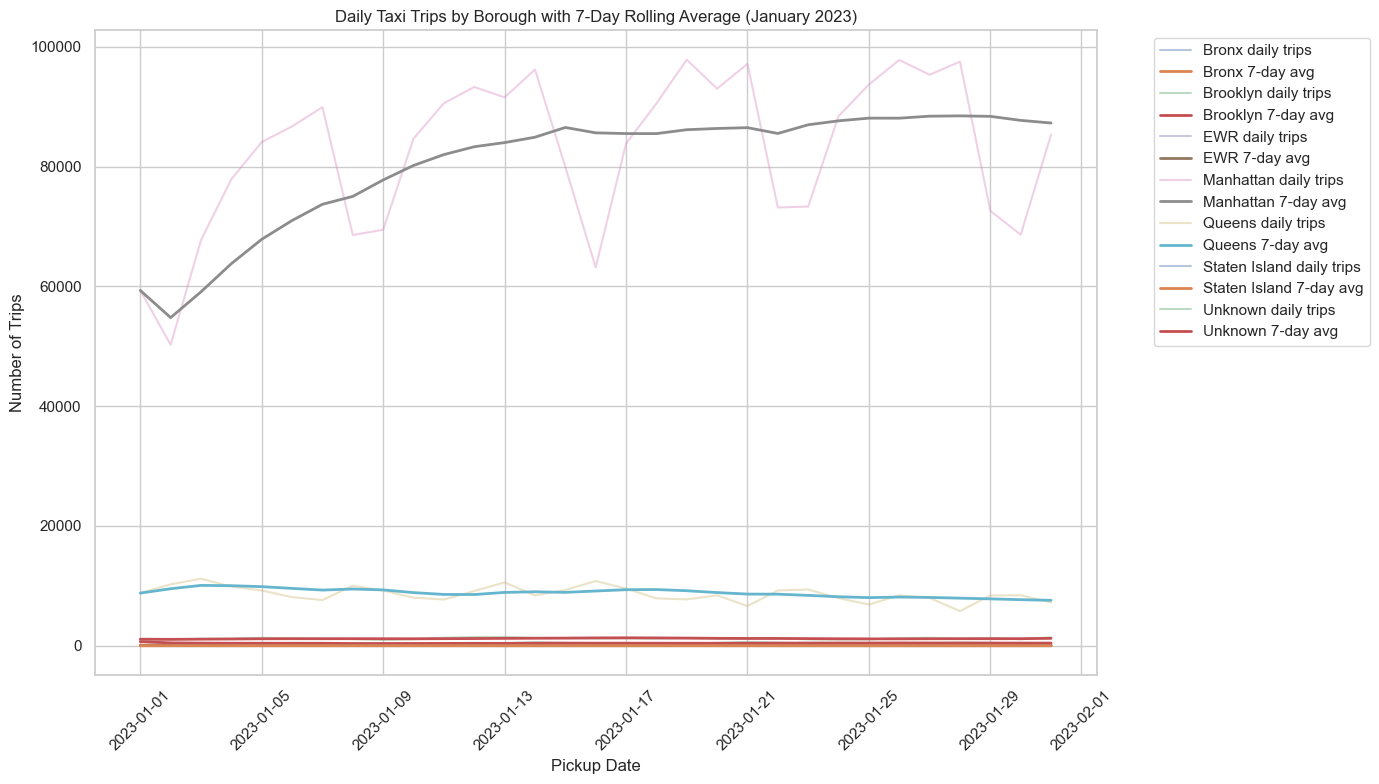

In [53]:
plt.figure(figsize=(14, 8))

for borough in daily_metrics["PU_borough"].dropna().unique():
    borough_data = daily_metrics[daily_metrics["PU_borough"] == borough]
    
    plt.plot(
        borough_data["pickup_date"],
        borough_data["daily_trip_count"],
        alpha=0.4,
        label=f"{borough} daily trips"
    )
    
    plt.plot(
        borough_data["pickup_date"],
        borough_data["rolling_7day_mean"],
        linewidth=2,
        label=f"{borough} 7-day avg"
    )

plt.title("Daily Taxi Trips by Borough with 7-Day Rolling Average (January 2023)")
plt.xlabel("Pickup Date")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Interpretation**

This time series shows daily taxi trip counts for each borough during January 2023, along with a 7-day rolling average that smooths short-term fluctuations.

Manhattan clearly has the highest trip volumes, with daily counts often exceeding 80,000–90,000 trips. Queens and Brooklyn follow with moderate volumes, while the Bronx and Staten Island have substantially lower daily trip counts.

The rolling averages reveal a gradual stabilization of demand across the month after the lower trip volumes observed during the New Year holiday period. The rolling trend also highlights weekly fluctuations in travel demand across boroughs.

### **Plot 2** 
-> Before/after cleaning distribution of trip_duration_min

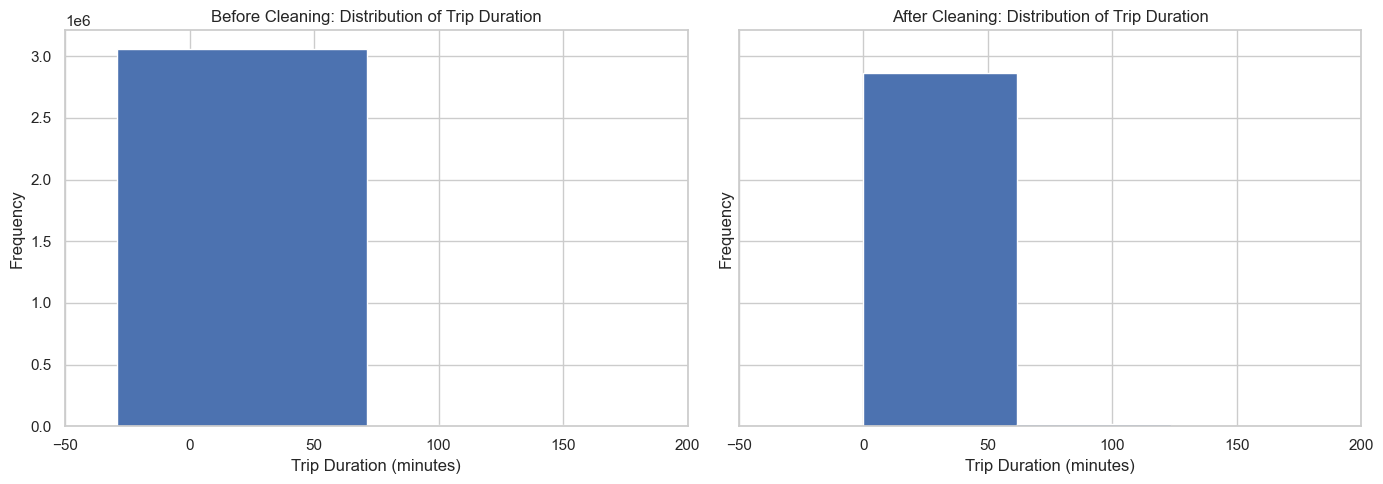

In [54]:
raw_plot_df = raw_df.copy()
raw_plot_df["tpep_pickup_datetime"] = pd.to_datetime(raw_plot_df["tpep_pickup_datetime"], errors="coerce")
raw_plot_df["tpep_dropoff_datetime"] = pd.to_datetime(raw_plot_df["tpep_dropoff_datetime"], errors="coerce")

raw_plot_df["trip_duration_min"] = (
    raw_plot_df["tpep_dropoff_datetime"] - raw_plot_df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].hist(raw_plot_df["trip_duration_min"].dropna(), bins=100)
axes[0].set_title("Before Cleaning: Distribution of Trip Duration")
axes[0].set_xlabel("Trip Duration (minutes)")
axes[0].set_ylabel("Frequency")
axes[0].set_xlim(-50, 200)

axes[1].hist(analysis_df["trip_duration_min"].dropna(), bins=100)
axes[1].set_title("After Cleaning: Distribution of Trip Duration")
axes[1].set_xlabel("Trip Duration (minutes)")
axes[1].set_ylabel("Frequency")
axes[1].set_xlim(-50, 200)

plt.tight_layout()
plt.show()

**Interpretation**

The distribution of trip durations before cleaning shows irregular values, including negative durations and extreme outliers. These values arise from data entry errors or inconsistent timestamps.

After applying the cleaning rules, the distribution becomes more realistic, with durations concentrated in a reasonable range of trip lengths. Removing invalid records ensures that subsequent analyses are based on valid trip data and prevents extreme values from distorting summary statistics and visualizations.

### **Plot 3**  
-> Relationship plot: trip_distance vs fare_amount

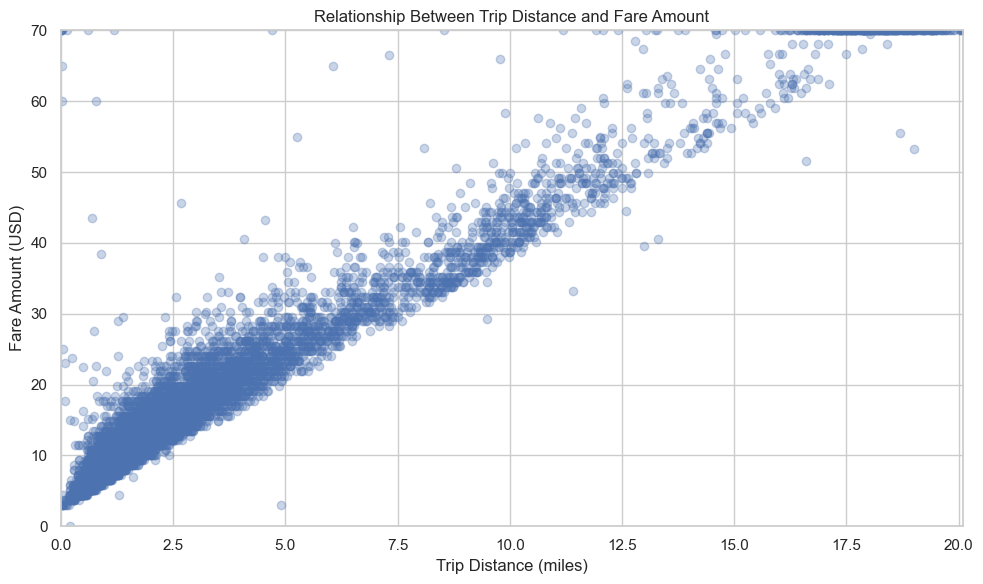

In [55]:
plot_sample = analysis_df.sample(n=min(10000, len(analysis_df)), random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(
    plot_sample["trip_distance"],
    plot_sample["fare_amount"],
    alpha=0.3
)

plt.title("Relationship Between Trip Distance and Fare Amount")
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Fare Amount (USD)")
plt.xlim(0, plot_sample["trip_distance"].quantile(0.99))
plt.ylim(0, plot_sample["fare_amount"].quantile(0.99))
plt.tight_layout()
plt.show()

**Interpretation**

The scatter plot shows a clear positive relationship between trip distance and fare amount. As trip distance increases, the fare generally increases as well, reflecting the fare structure used in taxi pricing.

Most trips occur within shorter distances (roughly under 5 miles), which is consistent with typical urban taxi usage. A few points lie above the main trend line, indicating additional charges such as surcharges, tolls, or tips that increase the total fare beyond the base distance-related amount.

### **Plot 4**  
-> Heatmap of average trips by weekday and pickup_hour

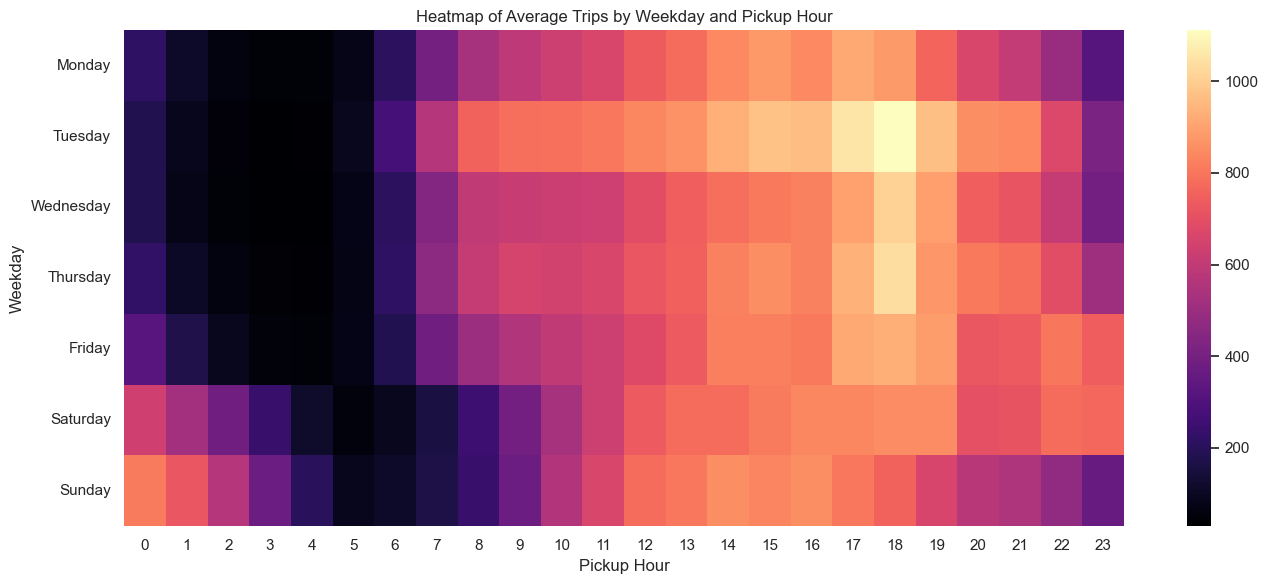

In [58]:
weekday_hour_daily = (
    analysis_df.groupby(["pickup_date", "weekday", "pickup_hour"], observed=False)
    .size()
    .reset_index(name="daily_trip_count")
)

heatmap_data = (
    weekday_hour_daily.groupby(["weekday", "pickup_hour"], observed=False)["daily_trip_count"]
    .mean()
    .reset_index()
)

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
heatmap_data["weekday"] = pd.Categorical(
    heatmap_data["weekday"],
    categories=weekday_order,
    ordered=True
)

heatmap_pivot = heatmap_data.pivot(
    index="weekday",
    columns="pickup_hour",
    values="daily_trip_count"
)

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_pivot, cmap=sns.color_palette("magma", as_cmap=True))

plt.title("Heatmap of Average Trips by Weekday and Pickup Hour")
plt.xlabel("Pickup Hour")
plt.ylabel("Weekday")
plt.tight_layout()
plt.show()

**Interpretation**

The heatmap illustrates how average taxi trip demand varies across both weekday and pickup hour. Darker colors represent higher average trip volumes.

Demand is lowest during the early morning hours (approximately 2–6 AM) and increases sharply during daytime and evening hours. Weekday demand generally peaks during the late afternoon and evening, which may correspond to commuting patterns and evening travel.

Weekend patterns differ slightly, with relatively higher activity late at night and in the early hours of Saturday and Sunday. Overall, the heatmap highlights strong time-of-day effects in taxi demand throughout the week.

## Summary

This analysis explored NYC Yellow Taxi trip data for **January 2023**. After cleaning and filtering the dataset, several statistical summaries, window metrics, exploratory analyses, and visualizations were performed to understand patterns in taxi demand and tipping behavior.

Key findings include:

- **Bronx** shows the strongest weekday effect among NYC boroughs, meaning its daily trip counts vary more across weekdays relative to its average volume.
- The two most anomalous days in total trip volume were **January 2 and January 1**, both showing unusually low demand, consistent with the **New Year holiday period**.
- **Tip rate is more strongly associated with pickup hour than with trip distance**, suggesting that time-of-day travel patterns influence tipping behavior more than trip length.
- Visualizations reveal clear patterns in taxi demand across boroughs, trip durations before and after cleaning, the relationship between trip distance and fare amount, and hourly travel patterns throughout the week.

Overall, the analysis highlights strong temporal patterns in taxi demand, including weekday commuting effects and time-of-day influences on tipping behavior.